# Titanic Passenger Survival — Data Analysis Workshop

A completed Python notebook based on the supplied workshop PDF and CSV. The objective is to identify **associations with survival**, rather than infer causes. Each record represents one passenger in this 891-record sample.

Run cells in order using Python 3 with pandas, NumPy, matplotlib, seaborn and IPython installed. Keep `titanic_dataset.csv` alongside this notebook; the loader also accepts the original upload filename. All outputs below were generated from the supplied CSV.

## 1. Project brief
Investigate how sex, class, age, fare, family relationships and embarkation relate to survival. Report group sizes alongside rates, consider missing data, and examine overlapping associations.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
candidates = [Path("titanic_dataset.csv"), Path("titanic_dataset (1).csv")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place the supplied Titanic CSV alongside this notebook.")
raw = pd.read_csv(data_path)
display(raw.head(), raw.tail())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S     

## 2. Data understanding

| Column | Meaning / analytical role |
|---|---|
| PassengerId | Passenger identifier; not a meaningful continuous predictor |
| Survived | Binary outcome: 0 died, 1 survived |
| Pclass | Ordered passenger class: 1, 2, 3 |
| Name | Passenger name; title can be extracted |
| Sex | Recorded sex category |
| Age | Age in years; fractional ages are valid for infants |
| SibSp | Siblings/spouses aboard |
| Parch | Parents/children aboard |
| Ticket | Ticket identifier; shared tickets can identify travelling groups |
| Fare | Recorded fare; potentially shared across a ticket group |
| Cabin | Cabin text with substantial missingness |
| Embarked | C: Cherbourg; Q: Queenstown; S: Southampton |

Storage types and analytical roles differ: Survived and Pclass are categorical even though stored as integers.

In [2]:
print("Rows, columns:", raw.shape)
print("Columns:", list(raw.columns))
raw.info()
display(raw.describe(), raw.describe(include="object"))
for col in ["Survived", "Sex", "Pclass", "Embarked", "SibSp", "Parch"]:
    print(f"\n{col} category counts:")
    print(raw[col].value_counts(dropna=False).sort_index())

Rows, columns: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891

## 3. Data quality check
Count missing values and duplicates, check allowed categories and ranges, and flag outliers using the 1.5×IQR rule. A statistical outlier is not automatically an error.

In [3]:
quality = pd.DataFrame({"missing": raw.isna().sum(), "missing_pct": raw.isna().mean()*100})
display(quality)
print("Duplicate rows:", raw.duplicated().sum())
print("Duplicate passenger IDs:", raw.PassengerId.duplicated().sum())
checks = {
    "invalid survival": (~raw.Survived.isin([0, 1])).sum(),
    "invalid class": (~raw.Pclass.isin([1, 2, 3])).sum(),
    "invalid sex": (~raw.Sex.isin(["male", "female"])).sum(),
    "invalid port": (~raw.Embarked.dropna().isin(["C", "Q", "S"])).sum(),
    "age outside 0–120": ((raw.Age < 0) | (raw.Age > 120)).sum(),
    "negative fare": (raw.Fare < 0).sum(),
    "invalid family counts": ((raw[["SibSp", "Parch"]] < 0) | (raw[["SibSp", "Parch"]] % 1 != 0)).sum().sum(),
}
print(checks)
rows = []
for col in ["Age", "Fare", "SibSp", "Parch"]:
    s = raw[col].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3-q1
    rows.append([col, s.min(), s.max(), s.skew(), ((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()])
display(pd.DataFrame(rows, columns=["variable", "minimum", "maximum", "skewness", "IQR flags"]))

             missing  missing_pct
PassengerId        0     0.000000
Survived           0     0.000000
Pclass             0     0.000000
Name               0     0.000000
Sex                0     0.000000
Age              177    19.865320
SibSp              0     0.000000
Parch              0     0.000000
Ticket             0     0.000000
Fare               0     0.000000
Cabin            687    77.104377
Embarked           2     0.224467
Duplicate rows: 0
Duplicate passenger IDs: 0
{'invalid survival': np.int64(0), 'invalid class': np.int64(0), 'invalid sex': np.int64(0), 'invalid port': np.int64(0), 'age outside 0–120': np.int64(0), 'negative fare': np.int64(0), 'invalid family counts': np.int64(0)}
  variable  minimum   maximum  skewness  IQR flags
0      Age     0.42   80.0000  0.389108         11
1     Fare     0.00  512.3292  4.787317        116
2    SibSp     0.00    8.0000  3.695352         46
3    Parch     0.00    6.0000  2.749117        213


## 4. Data preparation

Age has 177 missing values (19.9%), Cabin 687 (77.1%), and Embarked 2 (0.2%). No duplicate rows occur. Keep the raw data unchanged and retain plausible extreme fares and family counts.

Do not impute Age: age-specific analyses use available ages and report denominators. Label missing embarkation as Unknown instead of guessing a port. Cabin availability is an indicator of recorded information, not proof of whether a passenger had a cabin. FamilySize counts the passenger plus SibSp and Parch; it does not capture every possible travelling companion. Define children as under 16. Age bins are [0,16), [16,30), [30,45), [45,60), [60,∞). Fare quartiles are sample-relative, not historical fare categories. Ticket-sharing counts are restricted to this sample.

In [4]:
df = raw.copy()
df["Embarked"] = df.Embarked.fillna("Unknown")
df["FamilySize"] = df.SibSp + df.Parch + 1
df["IsAlone"] = df.FamilySize.eq(1)
df["AgeGroup"] = pd.cut(df.Age, [0,16,30,45,60,np.inf], right=False,
    labels=["0–15", "16–29", "30–44", "45–59", "60+"])
df["ChildAdult"] = pd.Series(np.where(df.Age < 16, "Child (<16)", "Adult (16+)"), index=df.index).where(df.Age.notna())
df["FareGroup"] = pd.qcut(df.Fare, 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
df["HasCabin"] = df.Cabin.notna()
df["TicketGroupSize"] = df.groupby("Ticket").Ticket.transform("size")
df["SharedTicket"] = df.TicketGroupSize.gt(1)
df["Title"] = df.Name.str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
def survival_by(keys):
    return df.groupby(keys, observed=True, dropna=False).Survived.agg(n="size", survivors="sum", survival_rate="mean").assign(survival_pct=lambda t:100*t.survival_rate)
def rate_plot(key, title):
    t = survival_by(key)
    ax = t.survival_pct.plot.bar(figsize=(7,3), color="#2787a5", rot=0)
    ax.set(title=title, ylabel="Survival (%)", xlabel=key, ylim=(0,100))
    plt.tight_layout(); plt.show()


## 5. Exploratory data analysis
Explore the population before interpreting survival. Fare is right-skewed, so a log(1+fare) view helps reveal its distribution without deleting expensive tickets.

IsAlone
Alone                   537
With recorded family    354
Name: count, dtype: int64


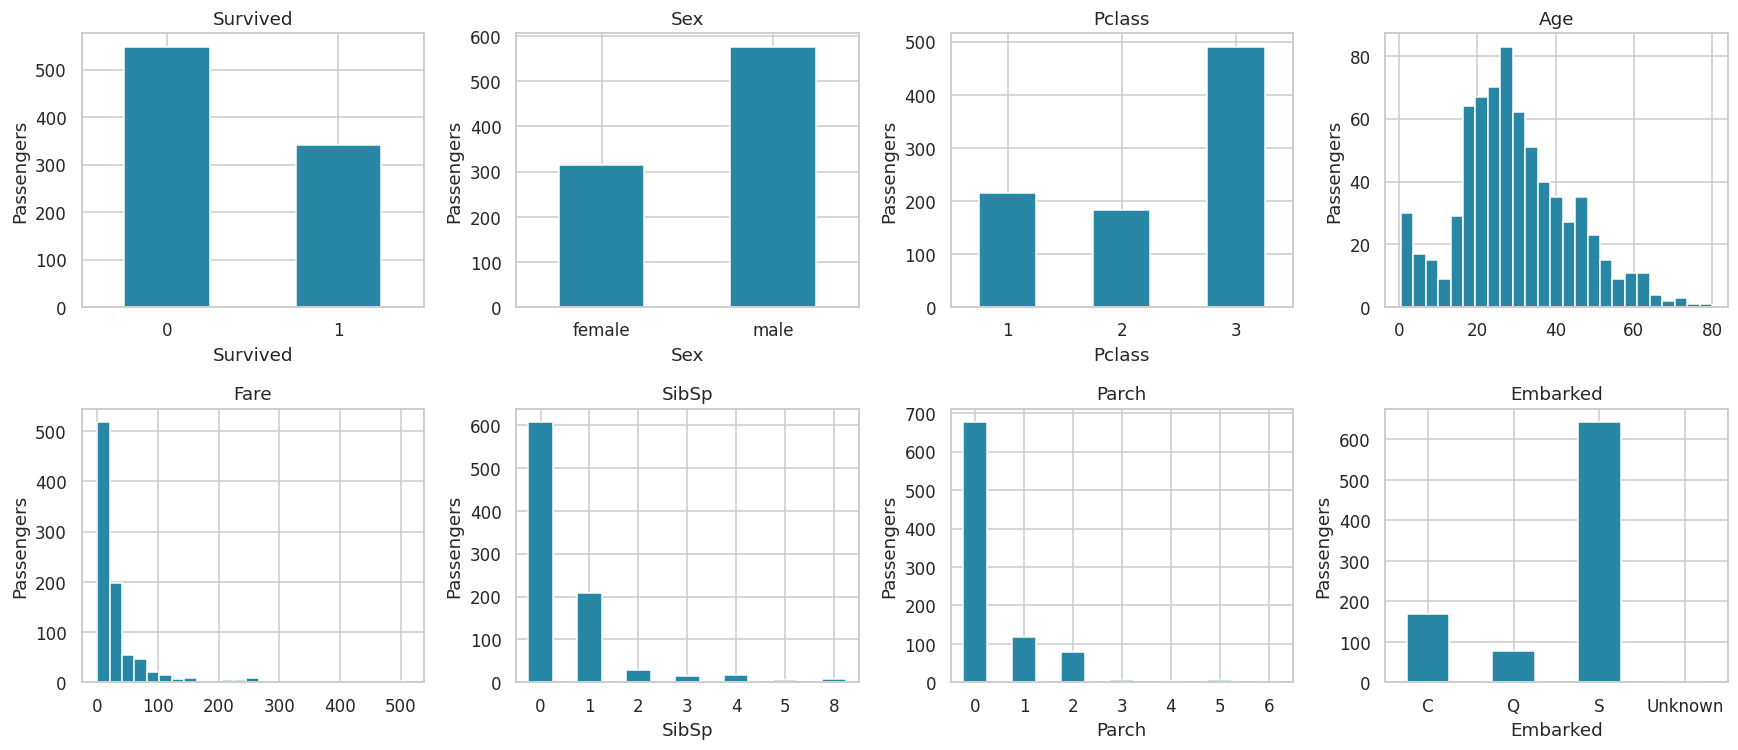

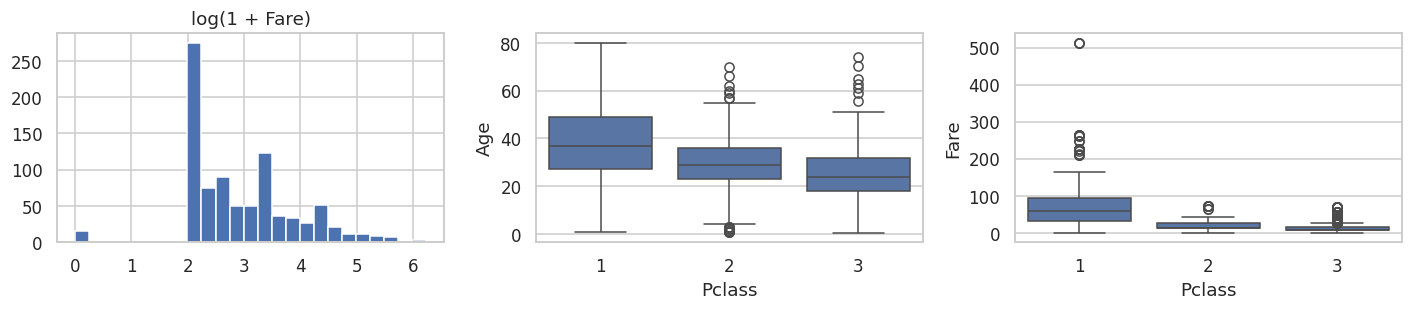

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16,7))
for ax, col in zip(axes.flat, ["Survived","Sex","Pclass","Age","Fare","SibSp","Parch","Embarked"]):
    if col in ["Age", "Fare"]:
        ax.hist(df[col].dropna(), bins=25, color="#2787a5")
    else:
        df[col].value_counts().sort_index().plot.bar(ax=ax, color="#2787a5", rot=0)
    ax.set_title(col); ax.set_ylabel("Passengers")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,3,figsize=(13,3))
axes[0].hist(np.log1p(df.Fare),bins=25); axes[0].set_title("log(1 + Fare)")
sns.boxplot(data=df, x="Pclass", y="Age", ax=axes[1])
sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[2])
plt.tight_layout(); plt.show()
display(df.IsAlone.value_counts().rename(index={True:"Alone",False:"With recorded family"}))

## 6. Survival analysis — all 30 questions
Each summary includes passenger counts. Percentages for age exclude missing ages except the explicitly shown missing-age category. Small groups can yield unstable rates.

### 1. Overall survival

In [6]:
print(f"Survived: {df.Survived.sum()} / {len(df)} ({df.Survived.mean():.1%})")

Survived: 342 / 891 (38.4%)


**Interpretation.** 342 of 891 passengers survived (38.4%); most passengers in this sample did not survive.

### 2. Survival by sex

          n  survivors  survival_rate  survival_pct
Sex                                                
female  314        233       0.742038     74.203822
male    577        109       0.188908     18.890815


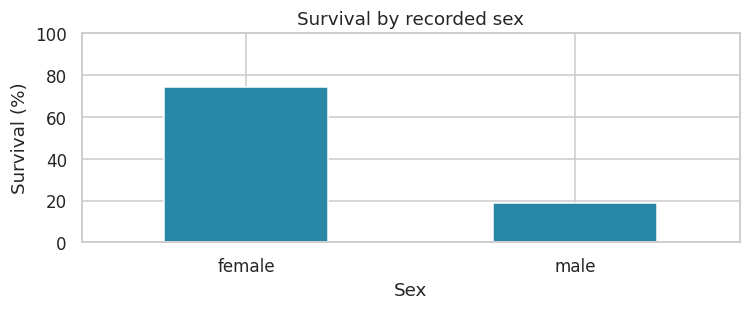

In [7]:
display(survival_by("Sex"))
rate_plot("Sex", "Survival by recorded sex")

**Interpretation.** Female survival was 74.2% versus 18.9% for males. This is a large association; question 12 checks it within class.

### 3. Survival by passenger class

          n  survivors  survival_rate  survival_pct
Pclass                                             
1       216        136       0.629630     62.962963
2       184         87       0.472826     47.282609
3       491        119       0.242363     24.236253


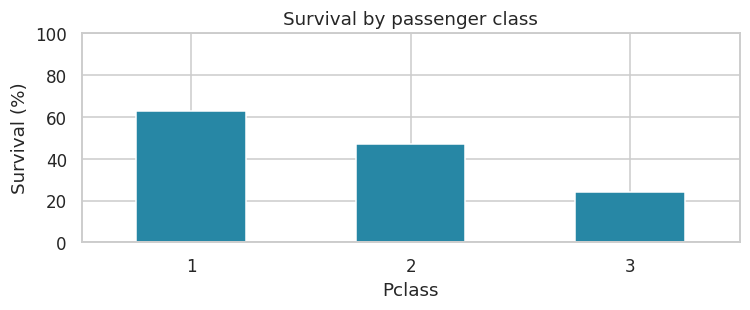

In [8]:
display(survival_by("Pclass"))
rate_plot("Pclass", "Survival by passenger class")

**Interpretation.** Survival decreases from first class (63.0%) to second (47.3%) and third (24.2%). Class is associated with resources and location, but these data do not establish the causal mechanism.

### 4. Age and survival

          count       mean  median
Survived                          
0           424  30.626179    28.0
1           290  28.343690    28.0
            n  survivors  survival_rate  survival_pct
AgeGroup                                             
0–15       83         49       0.590361     59.036145
16–29     301        107       0.355482     35.548173
30–44     215         91       0.423256     42.325581
45–59      89         36       0.404494     40.449438
60+        26          7       0.269231     26.923077
NaN       177         52       0.293785     29.378531


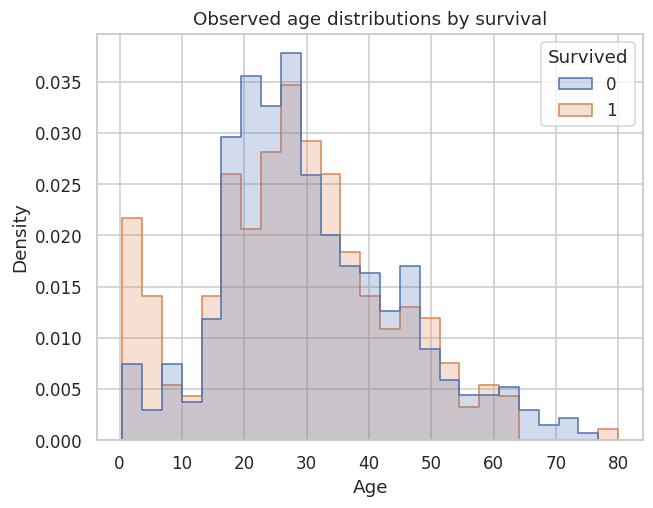

In [9]:
display(df.groupby("Survived").Age.agg(["count","mean","median"]))
display(survival_by("AgeGroup"))
sns.histplot(data=df, x="Age", hue="Survived", bins=25, stat="density", common_norm=False, element="step")
plt.title("Observed age distributions by survival"); plt.show()

**Interpretation.** Survivors were slightly younger on average (28.3 versus 30.6 years). The distributions overlap substantially, so age alone does not separate outcomes. Missing ages may bias the comparison.

### 5. Children versus adults

In [10]:
display(survival_by("ChildAdult"))

               n  survivors  survival_rate  survival_pct
ChildAdult                                              
Adult (16+)  631        241       0.381933     38.193344
Child (<16)   83         49       0.590361     59.036145
NaN          177         52       0.293785     29.378531


**Interpretation.** Children under 16 had a higher observed survival rate than adults. The missing-age group is retained in the table but excluded from the child/adult comparison; the cutoff is an analytical choice.

### 6. Fare and survival

          count       mean  median
Survived                          
0           549  22.117887    10.5
1           342  48.395408    26.0


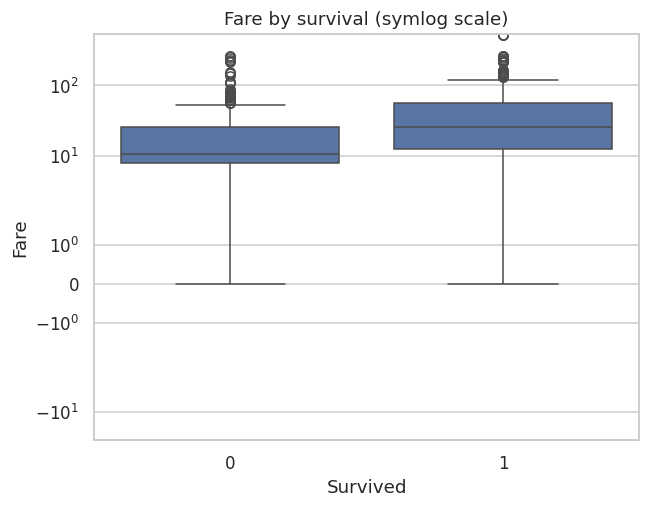

In [11]:
display(df.groupby("Survived").Fare.agg(["count","mean","median"]))
sns.boxplot(data=df,x="Survived",y="Fare"); plt.yscale("symlog"); plt.title("Fare by survival (symlog scale)"); plt.show()

**Interpretation.** Survivors paid higher average and median fares. Fare overlaps strongly with passenger class and may represent a shared ticket price; it should not be interpreted as a direct effect of paying more.

### 7. Embarkation and survival

In [12]:
display(survival_by("Embarked"))

            n  survivors  survival_rate  survival_pct
Embarked                                             
C         168         93       0.553571     55.357143
Q          77         30       0.389610     38.961039
S         644        217       0.336957     33.695652
Unknown     2          2       1.000000    100.000000


**Interpretation.** Cherbourg has a higher survival rate than Southampton or Queenstown. Unknown contains only two records, so its rate is not a stable comparison. Port differences may reflect class composition.

### 8. Siblings/spouses and survival

In [13]:
display(survival_by("SibSp"))

         n  survivors  survival_rate  survival_pct
SibSp                                             
0      608        210       0.345395     34.539474
1      209        112       0.535885     53.588517
2       28         13       0.464286     46.428571
3       16          4       0.250000     25.000000
4       18          3       0.166667     16.666667
5        5          0       0.000000      0.000000
8        7          0       0.000000      0.000000


**Interpretation.** Passengers with one sibling/spouse have higher survival than those with none; large SibSp groups fare poorly. This is not a monotonic relationship, and larger counts have few observations.

### 9. Parents/children and survival

In [14]:
display(survival_by("Parch"))

         n  survivors  survival_rate  survival_pct
Parch                                             
0      678        233       0.343658     34.365782
1      118         65       0.550847     55.084746
2       80         40       0.500000     50.000000
3        5          3       0.600000     60.000000
4        4          0       0.000000      0.000000
5        5          1       0.200000     20.000000
6        1          0       0.000000      0.000000


**Interpretation.** Passengers with one or two parents/children show higher rates than those with none. Extreme counts have small samples, making their percentages uncertain.

### 10. Family size and survival

              n  survivors  survival_rate  survival_pct
FamilySize                                             
1           537        163       0.303538     30.353818
2           161         89       0.552795     55.279503
3           102         59       0.578431     57.843137
4            29         21       0.724138     72.413793
5            15          3       0.200000     20.000000
6            22          3       0.136364     13.636364
7            12          4       0.333333     33.333333
8             6          0       0.000000      0.000000
11            7          0       0.000000      0.000000


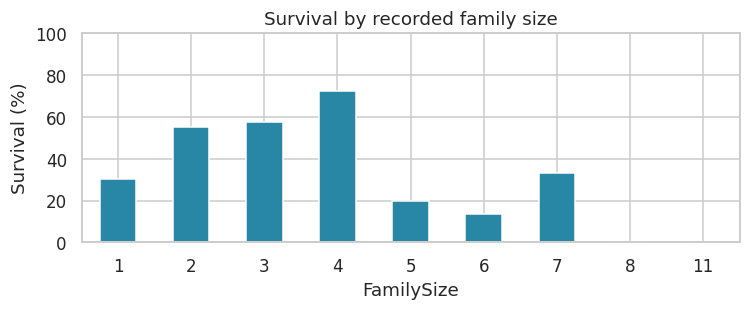

In [15]:
display(survival_by("FamilySize"))
rate_plot("FamilySize", "Survival by recorded family size")

**Interpretation.** Small family groups generally show better survival than lone passengers or large families. FamilySize measures recorded relatives, rather than all travelling companions.

### 11. Alone versus with family

In [16]:
display(survival_by("IsAlone"))

           n  survivors  survival_rate  survival_pct
IsAlone                                             
False    354        179       0.505650     50.564972
True     537        163       0.303538     30.353818


**Interpretation.** Those travelling with recorded family have higher survival than those classified as alone. Sex, age and class composition may account for part of the difference.

### 12. Sex and class together

                 n  survivors  survival_rate  survival_pct
Sex    Pclass                                             
female 1        94         91       0.968085     96.808511
       2        76         70       0.921053     92.105263
       3       144         72       0.500000     50.000000
male   1       122         45       0.368852     36.885246
       2       108         17       0.157407     15.740741
       3       347         47       0.135447     13.544669


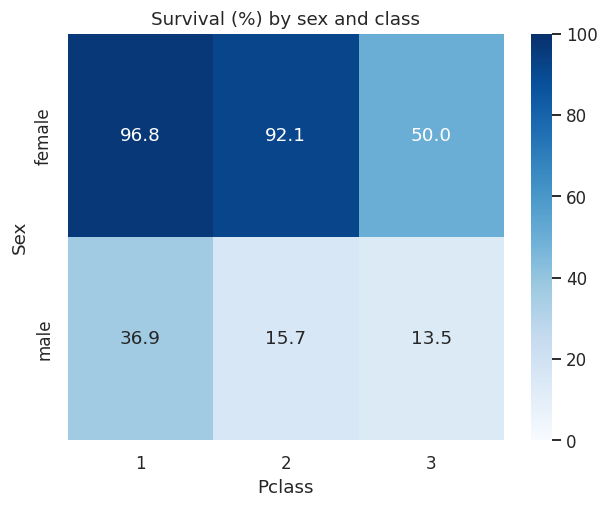

In [17]:
display(survival_by(["Sex","Pclass"]))
sns.heatmap(df.pivot_table(index="Sex",columns="Pclass",values="Survived",observed=True)*100,annot=True,fmt=".1f",vmin=0,vmax=100,cmap="Blues")
plt.title("Survival (%) by sex and class"); plt.show()

**Interpretation.** Females have higher survival within every class. Third-class female survival (50.0%) is much lower than first-class female survival (96.8%); males also show a class gradient.

### 13. Age across classes

In [18]:
display(df.groupby("Pclass").Age.agg(["count","mean","median"]))
display(survival_by(["Pclass","AgeGroup"]))

        count       mean  median
Pclass                          
1         186  38.233441    37.0
2         173  29.877630    29.0
3         355  25.140620    24.0
                   n  survivors  survival_rate  survival_pct
Pclass AgeGroup                                             
1      0–15        6          5       0.833333     83.333333
       16–29      49         36       0.734694     73.469388
       30–44      64         49       0.765625     76.562500
       45–59      50         27       0.540000     54.000000
       60+        17          5       0.294118     29.411765
       NaN        30         14       0.466667     46.666667
2      0–15       19         19       1.000000    100.000000
       16–29      69         29       0.420290     42.028986
       30–44      60         26       0.433333     43.333333
       45–59      21          8       0.380952     38.095238
       60+         4          1       0.250000     25.000000
       NaN        11          4       0.36

**Interpretation.** First-class passengers were older on average but survived more often. The class pattern therefore cannot be reduced to younger passengers surviving more; within-class age tables reveal overlapping associations.

### 14. Fare across classes

In [19]:
display(df.groupby("Pclass").Fare.agg(["count","mean","median"]))

        count       mean   median
Pclass                           
1         216  84.154687  60.2875
2         184  20.662183  14.2500
3         491  13.675550   8.0500


**Interpretation.** First class has much higher typical fares and survival than third class. The fare–survival pattern and class–survival pattern overlap substantially.

### 15. Port after considering class

In [20]:
display(survival_by(["Embarked","Pclass"]))
display(pd.crosstab(df.Embarked,df.Pclass,normalize="index").mul(100))

                   n  survivors  survival_rate  survival_pct
Embarked Pclass                                             
C        1        85         59       0.694118     69.411765
         2        17          9       0.529412     52.941176
         3        66         25       0.378788     37.878788
Q        1         2          1       0.500000     50.000000
         2         3          2       0.666667     66.666667
         3        72         27       0.375000     37.500000
S        1       127         74       0.582677     58.267717
         2       164         76       0.463415     46.341463
         3       353         67       0.189802     18.980170
Unknown  1         2          2       1.000000    100.000000
Pclass             1          2          3
Embarked                                  
C          50.595238  10.119048  39.285714
Q           2.597403   3.896104  93.506494
S          19.720497  25.465839  54.813665
Unknown   100.000000   0.000000   0.000000


**Interpretation.** Cherbourg includes a larger first-class share than Southampton. Rates within class differ from the aggregate comparison, showing that class composition influences the port pattern; sparse strata limit conclusions.

### 16. Fare quartiles

              n  survivors  survival_rate  survival_pct
FareGroup                                              
Q1 lowest   223         44       0.197309     19.730942
Q2          224         68       0.303571     30.357143
Q3          222        101       0.454955     45.495495
Q4 highest  222        129       0.581081     58.108108
Quartile boundaries: {0.0: 0.0, 0.25: 7.9104, 0.5: 14.4542, 0.75: 31.0, 1.0: 512.3292}


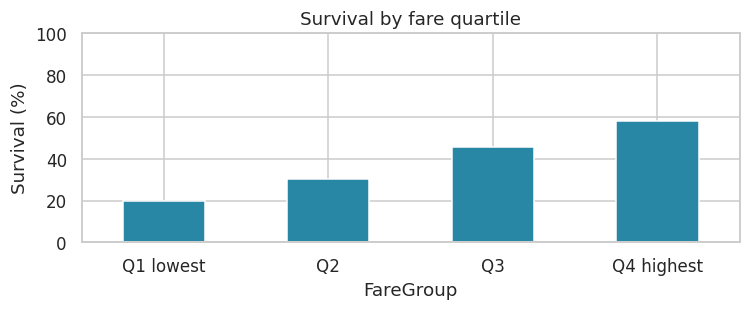

In [21]:
display(survival_by("FareGroup"))
print("Quartile boundaries:", df.Fare.quantile([0,.25,.5,.75,1]).to_dict())
rate_plot("FareGroup", "Survival by fare quartile")

**Interpretation.** The highest fare quartile has much higher survival than the lowest quartile. The middle groups need not be strictly monotonic; quartile boundaries are specific to this dataset.

### 17. Survival across age groups

            n  survivors  survival_rate  survival_pct
AgeGroup                                             
0–15       83         49       0.590361     59.036145
16–29     301        107       0.355482     35.548173
30–44     215         91       0.423256     42.325581
45–59      89         36       0.404494     40.449438
60+        26          7       0.269231     26.923077
NaN       177         52       0.293785     29.378531


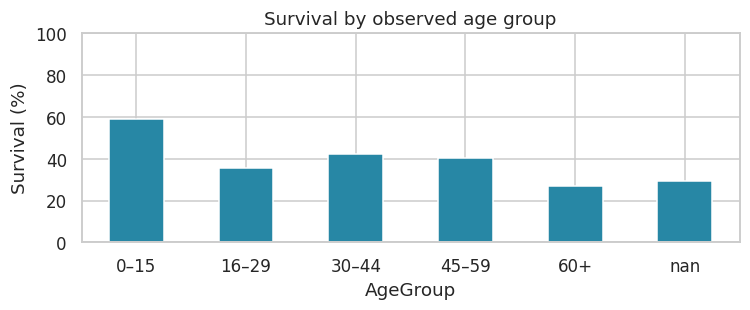

In [22]:
display(survival_by("AgeGroup"))
rate_plot("AgeGroup", "Survival by observed age group")

**Interpretation.** The youngest group has the highest observed rate; the oldest has the lowest. The relationship is not a simple linear decline across all intermediate groups, and missing age is a distinct group.

### 18. Highest/lowest sex–class combinations

In [23]:
t = survival_by(["Sex","Pclass"])
display(t.sort_values("survival_rate"))
print("Highest:", t.survival_rate.idxmax(), "Lowest:", t.survival_rate.idxmin())

                 n  survivors  survival_rate  survival_pct
Sex    Pclass                                             
male   3       347         47       0.135447     13.544669
       2       108         17       0.157407     15.740741
       1       122         45       0.368852     36.885246
female 3       144         72       0.500000     50.000000
       2        76         70       0.921053     92.105263
       1        94         91       0.968085     96.808511
Highest: ('female', np.int64(1)) Lowest: ('male', np.int64(3))


**Interpretation.** First-class females have the highest rate (96.8%), and third-class males the lowest (13.5%). These are sample rates, not guarantees for individual passengers.

### 19. Mean fare by outcome

In [24]:
display(df.groupby("Survived").Fare.agg(["count","mean","median"]))

          count       mean  median
Survived                          
0           549  22.117887    10.5
1           342  48.395408    26.0


**Interpretation.** Mean fare is 48.40 for survivors versus 22.12 for non-survivors. Medians also differ; reporting them reduces reliance on means affected by expensive tickets.

### 20. Mean age by outcome

In [25]:
display(df.groupby("Survived").Age.agg(["count","mean","median"]))

          count       mean  median
Survived                          
0           424  30.626179    28.0
1           290  28.343690    28.0


**Interpretation.** Mean observed age is 28.34 among survivors and 30.63 among non-survivors. This modest difference uses only 290 survivors and 424 non-survivors with recorded ages.

### 21. Highest/lowest age groups

In [26]:
t = survival_by("AgeGroup")
t = t.loc[t.index.notna()]
display(t.sort_values("survival_rate"))
print("Highest:", t.survival_rate.idxmax(), "Lowest:", t.survival_rate.idxmin())

            n  survivors  survival_rate  survival_pct
AgeGroup                                             
60+        26          7       0.269231     26.923077
16–29     301        107       0.355482     35.548173
45–59      89         36       0.404494     40.449438
30–44     215         91       0.423256     42.325581
0–15       83         49       0.590361     59.036145
Highest: 0–15 Lowest: 60+


**Interpretation.** For the chosen bins, ages 0–15 have the highest survival and ages 60+ the lowest. The oldest group is small; different age cutoffs may change rankings.

### 22. Class with highest typical fare

In [27]:
display(df.groupby("Pclass").Fare.median().rename("median_fare"))

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: median_fare, dtype: float64


**Interpretation.** First class has the highest median fare (60.29), compared with 14.25 in second and 8.05 in third. Median defines typical fare here because the distribution is skewed.

### 23. Are high fares concentrated in first class?

In [28]:
high = df.FareGroup.eq("Q4 highest")
display(df.loc[high,"Pclass"].value_counts().sort_index().rename("high_fare_passengers"))
display(pd.crosstab(df.Pclass,df.FareGroup,normalize="index").mul(100))
display(survival_by(["Pclass","FareGroup"]))

Pclass
1    159
2     22
3     41
Name: high_fare_passengers, dtype: int64
FareGroup  Q1 lowest         Q2         Q3  Q4 highest
Pclass                                                
1           2.777778   0.000000  23.611111   73.611111
2           3.260870  46.739130  38.043478   11.956522
3          42.973523  28.105906  20.570265    8.350305
                     n  survivors  survival_rate  survival_pct
Pclass FareGroup                                              
1      Q1 lowest     6          0       0.000000      0.000000
       Q3           51         27       0.529412     52.941176
       Q4 highest  159        109       0.685535     68.553459
2      Q1 lowest     6          0       0.000000      0.000000
       Q2           86         33       0.383721     38.372093
       Q3           70         42       0.600000     60.000000
       Q4 highest   22         12       0.545455     54.545455
3      Q1 lowest   211         44       0.208531     20.853081
       Q2          1

**Interpretation.** Most top-quartile fares occur in first class. A raw fare comparison partially reflects class differences; within-class groups help investigate this, but do not fully adjust for other confounders.

### 24. Cabin information and survival

In [29]:
display(survival_by("HasCabin"))
display(pd.crosstab(df.HasCabin,df.Pclass,normalize="index").mul(100))

            n  survivors  survival_rate  survival_pct
HasCabin                                             
False     687        206       0.299854     29.985444
True      204        136       0.666667     66.666667
Pclass            1          2          3
HasCabin                                 
False      5.822416  24.454148  69.723435
True      86.274510   7.843137   5.882353


**Interpretation.** Passengers with recorded cabins survive more often. Cabin missingness is extensive and linked to class; this is an association with documentation availability, not evidence that missing cabin text caused lower survival.

### 25. Shared versus unique tickets

In [30]:
display(survival_by("SharedTicket"))
display(survival_by("TicketGroupSize"))

                n  survivors  survival_rate  survival_pct
SharedTicket                                             
False         547        163       0.297989     29.798903
True          344        179       0.520349     52.034884
                   n  survivors  survival_rate  survival_pct
TicketGroupSize                                             
1                547        163       0.297989     29.798903
2                188        108       0.574468     57.446809
3                 63         44       0.698413     69.841270
4                 44         22       0.500000     50.000000
5                 10          0       0.000000      0.000000
6                 18          0       0.000000      0.000000
7                 21          5       0.238095     23.809524


**Interpretation.** Passengers with shared tickets show higher aggregate survival than those with unique tickets. Shared tickets may reflect families or other companions; the counts cover this sample rather than the full ship, and passengers within tickets are not independent.

### 26. Titles extracted from names

In [31]:
display(survival_by("Title").sort_values("n",ascending=False))

                n  survivors  survival_rate  survival_pct
Title                                                    
Mr            517         81       0.156673     15.667311
Miss          182        127       0.697802     69.780220
Mrs           125         99       0.792000     79.200000
Master         40         23       0.575000     57.500000
Dr              7          3       0.428571     42.857143
Rev             6          0       0.000000      0.000000
Mlle            2          2       1.000000    100.000000
Major           2          1       0.500000     50.000000
Col             2          1       0.500000     50.000000
Capt            1          0       0.000000      0.000000
Lady            1          1       1.000000    100.000000
Don             1          0       0.000000      0.000000
Jonkheer        1          0       0.000000      0.000000
Mme             1          1       1.000000    100.000000
Ms              1          1       1.000000    100.000000
Sir           

**Interpretation.** Mrs, Miss and Master tend to show higher survival than Mr. Titles encode overlapping sex, age and social information; rare titles have too few observations for reliable comparisons.

### 27. Numerical correlations

                 Survived  Pclass    Age  SibSp  Parch   Fare  FamilySize  \
Survived            1.000  -0.338 -0.077 -0.035  0.082  0.257       0.017   
Pclass             -0.338   1.000 -0.369  0.083  0.018 -0.549       0.066   
Age                -0.077  -0.369  1.000 -0.308 -0.189  0.096      -0.302   
SibSp              -0.035   0.083 -0.308  1.000  0.415  0.160       0.891   
Parch               0.082   0.018 -0.189  0.415  1.000  0.216       0.783   
Fare                0.257  -0.549  0.096  0.160  0.216  1.000       0.217   
FamilySize          0.017   0.066 -0.302  0.891  0.783  0.217       1.000   
IsAlone            -0.203   0.135  0.198 -0.584 -0.583 -0.272      -0.691   
HasCabin            0.317  -0.726  0.250 -0.040  0.037  0.482      -0.009   
TicketGroupSize     0.038  -0.003 -0.254  0.662  0.593  0.346       0.748   

                 IsAlone  HasCabin  TicketGroupSize  
Survived          -0.203     0.317            0.038  
Pclass             0.135    -0.726          

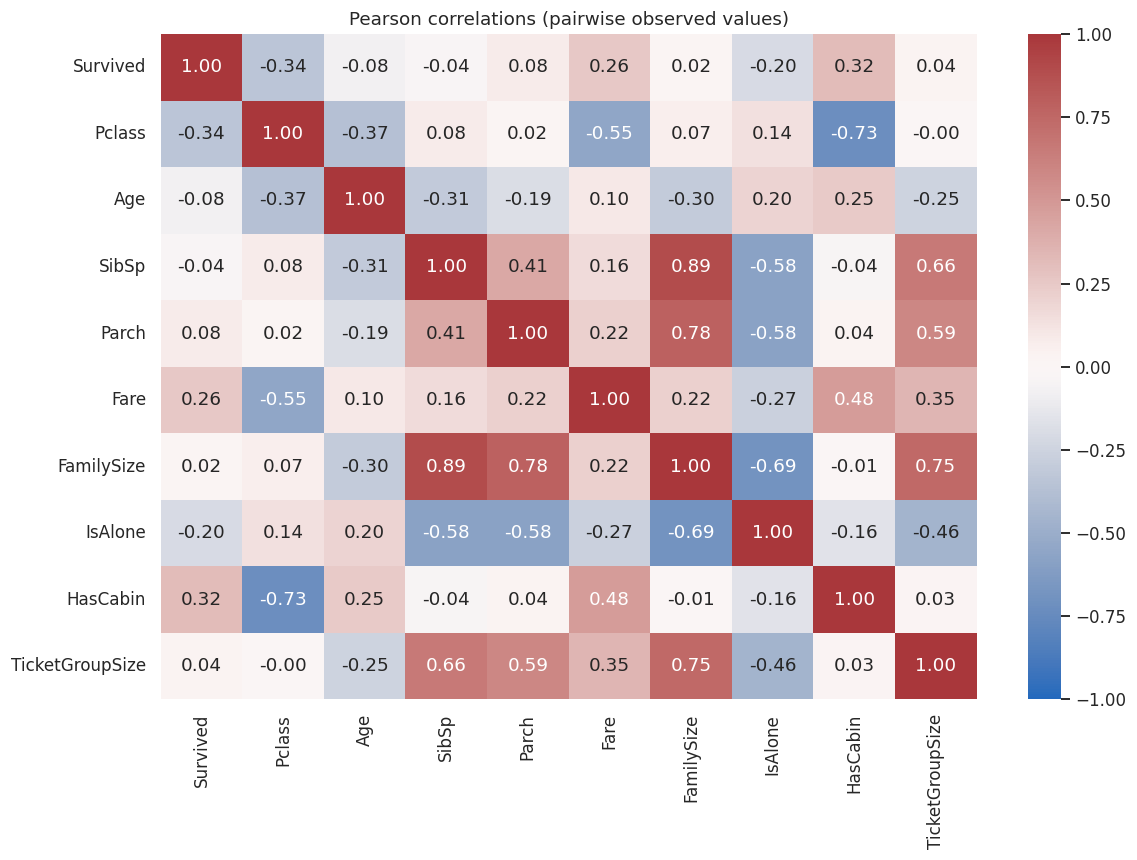

In [32]:
cols = ["Survived","Pclass","Age","SibSp","Parch","Fare","FamilySize","IsAlone","HasCabin","TicketGroupSize"]
corr = df[cols].corr()
display(corr.round(3))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="vlag",center=0,vmin=-1,vmax=1)
plt.gcf().set_size_inches(11,8); plt.title("Pearson correlations (pairwise observed values)"); plt.tight_layout(); plt.show()

**Interpretation.** Survival is negatively correlated with numerical class code and positively correlated with fare and cabin availability. Fare and class are themselves related. Age has a weak linear correlation despite age-group differences. Sex is absent because it is text; its exclusion does not imply weak association. Derived family variables are mechanically related, and pairwise correlations may use different sample sizes.

### 28. Three clearest survival associations

In [33]:
for key in ["Sex","Pclass","HasCabin"]:
    display(survival_by(key))

          n  survivors  survival_rate  survival_pct
Sex                                                
female  314        233       0.742038     74.203822
male    577        109       0.188908     18.890815
          n  survivors  survival_rate  survival_pct
Pclass                                             
1       216        136       0.629630     62.962963
2       184         87       0.472826     47.282609
3       491        119       0.242363     24.236253
            n  survivors  survival_rate  survival_pct
HasCabin                                             
False     687        206       0.299854     29.985444
True      204        136       0.666667     66.666667


**Interpretation.** Sex, passenger class and cabin-information availability show three clear descriptive contrasts. Cabin availability overlaps strongly with class and documentation, so these are not three independent drivers. This selection uses group contrasts, not a formal causal ranking or predictive model.

### 29. Possible confounding

In [34]:
display(survival_by(["Pclass","FareGroup"]))
display(pd.crosstab(df.Embarked,df.Pclass,normalize="index").mul(100))

                     n  survivors  survival_rate  survival_pct
Pclass FareGroup                                              
1      Q1 lowest     6          0       0.000000      0.000000
       Q3           51         27       0.529412     52.941176
       Q4 highest  159        109       0.685535     68.553459
2      Q1 lowest     6          0       0.000000      0.000000
       Q2           86         33       0.383721     38.372093
       Q3           70         42       0.600000     60.000000
       Q4 highest   22         12       0.545455     54.545455
3      Q1 lowest   211         44       0.208531     20.853081
       Q2          138         35       0.253623     25.362319
       Q3          101         32       0.316832     31.683168
       Q4 highest   41          8       0.195122     19.512195
Pclass             1          2          3
Embarked                                  
C          50.595238  10.119048  39.285714
Q           2.597403   3.896104  93.506494
S        

**Interpretation.** Passenger class is a possible confounder of fare and survival because class is associated with both. Class composition also helps explain port differences. Stratification exposes overlapping relationships but does not establish causality or eliminate all confounding.

### 30. Limitations and conclusions to avoid

In [35]:
print(f"Missing age: {raw.Age.isna().mean():.1%}; missing cabin: {raw.Cabin.isna().mean():.1%}")
print("Passengers:", len(raw), "Unique tickets:", raw.Ticket.nunique())

Missing age: 19.9%; missing cabin: 77.1%
Passengers: 891 Unique tickets: 681


**Interpretation.** This is an observational sample of 891 passengers, not the full ship population. Missing data may be systematic, sparse groups yield unstable estimates, ticket/family members may share outcomes, and relevant variables such as exact location and rescue access are unavailable. Avoid causal claims, deterministic predictions, generalization to all passengers without checking representativeness, and treating these exploratory comparisons as independently confirmed hypotheses.

## 7. Key findings

- Overall survival was **38.4%** (342 of 891).
- Females survived at **74.2%**, versus **18.9%** for males; the direction remains within each class.
- Survival decreased across first, second and third class: **63.0%, 47.3%, 24.2%**.
- First-class females had **96.8%** survival, compared with **13.5%** for third-class males.
- Children had higher observed survival; the age relationship is not captured well by a single linear correlation.
- Fare and cabin availability show clear associations that overlap with class. Small recorded families generally fare better than lone passengers or large families.
- Embarkation comparisons depend partly on class composition. Missing ages and sparse subgroups limit interpretation.

## 8. Conclusion

The analysis examined survival patterns in 891 Titanic passenger records. Survival was strongly associated with recorded sex and passenger class, including large differences when both were considered together. Females had 74.2% survival versus 18.9% for males, while first-class survival was 63.0% compared with 24.2% in third class. Children and passengers in smaller family groups generally had better outcomes; higher fares and available cabin information were also associated with survival and overlapped substantially with class.

These results describe patterns in this sample rather than proving what caused survival. Missing age for 19.9% of passengers, missing cabin for 77.1%, small subgroups, related passengers and unmeasured rescue conditions limit the analysis. The central finding is that survival varied sharply across social and demographic groups, while apparently separate associations often reflected overlapping passenger characteristics.